In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

print("Ready")

Ready


In [6]:
universe = [
    # Tech
    "AAPL", "MSFT", "NVDA", "META", "GOOGL",
    # Finance
    "JPM", "BAC", "GS", "V", "MA",
    # Healthcare
    "JNJ", "UNH", "PFE", "ABBV", "MRK",
    # Consumer & Energy
    "AMZN", "TSLA", "XOM", "CVX", "WMT"
]

print(f"Universe: {len(universe)} stocks")
print(universe)
    

Universe: 20 stocks
['AAPL', 'MSFT', 'NVDA', 'META', 'GOOGL', 'JPM', 'BAC', 'GS', 'V', 'MA', 'JNJ', 'UNH', 'PFE', 'ABBV', 'MRK', 'AMZN', 'TSLA', 'XOM', 'CVX', 'WMT']


In [7]:
# Download 2 years of data for all 20 stocks
raw = yf.download(universe,
                  start="2022-01-01",
                  end="2024-01-01",
                  auto_adjust=True)
# Extract just closing prices
prices = raw["Close"]
prices.columns = prices.columns.get_level_values(0)

print(f"Shape: {prices.shape}")
print(f"Stocks loaded: {prices.columns.tolist()}")

[*********************100%***********************]  20 of 20 completed

Shape: (501, 20)
Stocks loaded: ['AAPL', 'ABBV', 'AMZN', 'BAC', 'CVX', 'GOOGL', 'GS', 'JNJ', 'JPM', 'MA', 'META', 'MRK', 'MSFT', 'NVDA', 'PFE', 'TSLA', 'UNH', 'V', 'WMT', 'XOM']


In [8]:
def momentum_signal(prices, lookback=252, skip=21):
    """
    Calculate 12-1 month momentum for each stock.
    lookback = 252 trading days (12 months)
    skip = 21 trading days (1 month, to avoid reversal)
    Returns a Series of momentum scores ranked from highest to lowest.
    """
    # Price 12 months ago
    price_12m_ago = prices.shift(lookback)

    # Price 1 month ago (skip last month)
    price_1m_ago = prices.shift(skip)

    # Momentum = return from 12 months ago to 1 month ago
    momentum = (price_1m_ago / price_12m_ago) -1
    
    return momentum

# Calculate momentum as of the latest date
mom = momentum_signal(prices)
latest_mom = mom.iloc[-1].dropna().sort_values(ascending=False)

print("MOMENTUM SCORES (12-1 month)")
print("=" * 35)
for ticker, score in latest_mom.items():
    bar = "█" * int(abs(score) * 20)
    sign = "+" if score > 0 else ""
    print(f"  {ticker:<6} {sign}{score:>7.2%}  {bar}")
print("=" * 35)

MOMENTUM SCORES (12-1 month)
  NVDA   +243.10%  ████████████████████████████████████████████████
  META   +187.32%  █████████████████████████████████████
  TSLA   +116.61%  ███████████████████████
  AMZN   + 78.83%  ███████████████
  MSFT   + 62.97%  ████████████
  GOOGL  + 56.93%  ███████████
  AAPL   + 51.09%  ██████████
  V      + 25.01%  █████
  MA     + 20.58%  ████
  JPM    + 19.98%  ███
  WMT    + 11.74%  ██
  GS     +  2.98%  
  UNH    +  2.41%  
  XOM     -2.35%  
  BAC     -5.38%  █
  MRK     -7.08%  █
  ABBV   -11.18%  ██
  JNJ    -11.28%  ██
  CVX    -15.49%  ███
  PFE    -38.10%  ███████


In [9]:
top5    = latest_mom.head(5)
bottom5 = latest_mom.tail(5)

print("TOP 5 — LONG CANDIDATES")
print("=" * 35)
for ticker, score in top5.items():
    print(f"  {ticker:<6} +{score:>7.2%}")

print("\nBOTTOM 5 — SHORT CANDIDATES")
print("=" * 35)
for ticker, score in bottom5.items():
    print(f"  {ticker:<6}  {score:>7.2%}")

TOP 5 — LONG CANDIDATES
  NVDA   +243.10%
  META   +187.32%
  TSLA   +116.61%
  AMZN   + 78.83%
  MSFT   + 62.97%

BOTTOM 5 — SHORT CANDIDATES
  MRK      -7.08%
  ABBV    -11.18%
  JNJ     -11.28%
  CVX     -15.49%
  PFE     -38.10%


[*********************100%***********************]  1 of 1 completed


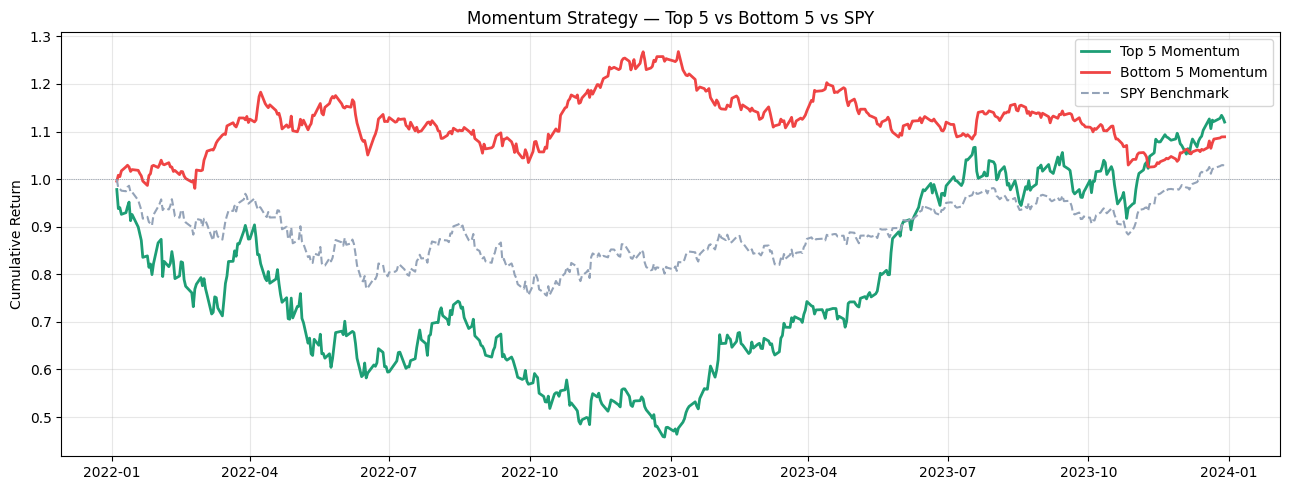


Top 5 final return    : 11.98%
Bottom 5 final return : 8.88%
Long-short spread     : 0.03x


In [10]:
# Compare cumulative returns: top 5 vs bottom 5
top_tickers    = top5.index.tolist()
bottom_tickers = bottom5.index.tolist()

# Calculate cumulative returns for each group
returns = prices.pct_change().dropna()

top_returns    = returns[top_tickers].mean(axis=1)
bottom_returns = returns[bottom_tickers].mean(axis=1)
spy_returns    = yf.download("SPY", start="2022-01-01",
                              end="2024-01-01",
                              auto_adjust=True)["Close"].pct_change().dropna()
spy_returns.index = spy_returns.index.get_level_values(0) if hasattr(spy_returns.index, 'get_level_values') else spy_returns.index

top_cum    = (1 + top_returns).cumprod()
bottom_cum = (1 + bottom_returns).cumprod()
spy_cum    = (1 + spy_returns.squeeze()).cumprod()

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(top_cum,    color='#1D9E75', lw=2,   label='Top 5 Momentum')
ax.plot(bottom_cum, color='#ef4444', lw=2,   label='Bottom 5 Momentum')
ax.plot(spy_cum,    color='#94a3b8', lw=1.5,
        linestyle='--', label='SPY Benchmark')
ax.axhline(1, color='#64748b', lw=0.5, linestyle=':')
ax.set_title('Momentum Strategy — Top 5 vs Bottom 5 vs SPY')
ax.set_ylabel('Cumulative Return')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print the spread
final_spread = top_cum.iloc[-1] - bottom_cum.iloc[-1]
print(f"\nTop 5 final return    : {top_cum.iloc[-1]-1:.2%}")
print(f"Bottom 5 final return : {bottom_cum.iloc[-1]-1:.2%}")
print(f"Long-short spread     : {final_spread:.2f}x")

In [14]:
universe = [
    "AAPL", "MSFT", "NVDA", "META", "GOOGL",
    "JPM", "BAC", "GS", "V", "MA",
    "JNJ", "UNH", "PFE", "ABBV", "MRK",
    "AMZN", "TSLA", "XOM", "CVX", "WMT"
]

def momentum_screener(prices, top_n=5):
    """
    Full momentum screener using pre-downloaded prices.
    Ranks stocks by 12-1 month momentum.
    """
    lookback = 252  # 12 months
    skip     = 21   # 1 month

    # Check we have enough data
    if len(prices) < lookback + skip:
        print(f"Need at least {lookback+skip} rows, have {len(prices)}")
        return None

    # Momentum = price 1 month ago / price 12 months ago - 1
    price_1m  = prices.iloc[-(skip+1)]
    price_12m = prices.iloc[-(lookback+skip+1)]

    momentum = (price_1m / price_12m - 1).dropna()
    momentum = momentum.sort_values(ascending=False)

    top    = momentum.head(top_n)
    bottom = momentum.tail(top_n)

    print(f"\n{'='*45}")
    print(f"  MOMENTUM SCREENER")
    print(f"  Date: {prices.index[-1].date()}")
    print(f"{'='*45}")
    print(f"\n  LONG (Top {top_n}):")
    for t, s in top.items():
        print(f"    {t:<6} {s:>+8.2%}")
    print(f"\n  SHORT (Bottom {top_n}):")
    for t, s in bottom.items():
        print(f"    {t:<6} {s:>+8.2%}")
    print(f"{'='*45}")

    return {"long": top, "short": bottom, "all": momentum}

# Run using the prices we already downloaded
signals = momentum_screener(prices, top_n=5)



  MOMENTUM SCREENER
  Date: 2023-12-29

  LONG (Top 5):
    META   +205.39%
    NVDA   +204.35%
    MSFT    +58.09%
    AMZN    +55.74%
    GOOGL   +40.54%

  SHORT (Bottom 5):
    ABBV     -9.05%
    JNJ     -11.62%
    BAC     -15.39%
    CVX     -16.14%
    PFE     -36.56%
